# Regional Ozone Trends near Lake Michigan

This notebook compares ozone timeseries from ozone monitors near the south and west shores of Lake Michigan.
solid lines: lakefront stations, dahsed lines: inland stations.

Load standard python packages.

In [19]:
# Standard library
import datetime as dt

# Third party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyaqsapi as aqs
import pytz
from suntime import Sun

# Local
from aqs_utils import wrangle_aqs_timeseries
from aqs_codes import o3           # AQSParameter — e.g. replaces "44201"
from fips_codes import FIPS        # SimpleNamespace — replaces raw FIPS strings
from aqi_colors import aqi_boxes  

Set up credentials to use the EPA Air Quality Systerm (AQS) API

## Credentials
The cell below loads AQS API credentials from a `.env` file. If you prefer to enter them directly, replace the `load_dotenv()` block with:
```python
aqs.aqs_credentials(username="your_email@example.com", key="your_key")
```

In [20]:
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv()

AQS_USER = os.getenv("AQS_USER")
AQS_KEY = os.getenv("AQS_KEY")

if not AQS_USER or not AQS_KEY:
    raise RuntimeError(
        "Missing EPA AQS credentials. Create a .env file in this directory with:\n"
        "AQS_USER=your_email@example.com\n"
        "AQS_KEY=your_aqs_key\n\n"
        "Register for a free key at: "
        "https://aqs.epa.gov/aqsweb/documents/data_api.html"
    )

aqs.aqs_credentials(username=AQS_USER, key=AQS_KEY)

In [21]:
YEAR     = 2020
START_DT = dt.datetime(YEAR, 6, 17)   # naive — for AQS API calls
END_DT   = dt.datetime(YEAR, 6, 21)   # naive — for AQS API calls

CDT      = pytz.timezone("America/Chicago")
START_DT_LOCAL = CDT.localize(START_DT)  # aware — for suntime and plotting
END_DT_LOCAL   = CDT.localize(END_DT)    # aware — for suntime and plotting

## Station Selectoin

Build a list of sites using the list of stations below

In [22]:
lm_o3_monitors = aqs.bybox.monitors(
    parameter=o3.code,
    bdate=START_DT,
    edate=END_DT,
    minlat="41", maxlat="46.5",
    minlon="-89", maxlon="-85")

display(lm_o3_monitors)

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,031,0001,44201,1,Ozone,1988-06-01,NaN,None,AREA,...,4500 W. 123RD ST.,Illinois,Cook,Alsip,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
1,17,031,0032,44201,1,Ozone,1987-04-01,NaN,None,AREA,...,3300 E. CHELTENHAM PL.,Illinois,Cook,Chicago,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
2,17,031,1003,44201,2,Ozone,1979-01-01,NaN,None,AREA,...,6545 W. HURLBUT ST.,Illinois,Cook,Chicago,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
3,17,031,1601,44201,1,Ozone,1983-01-01,NaN,None,AREA,...,729 HOUSTON,Illinois,Cook,Lemont,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
4,17,031,4002,44201,1,Ozone,1983-01-01,NaN,None,AREA,...,1820 S. 51ST AVE.,Illinois,Cook,Cicero,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,17,031,3103,44201,2,Ozone,2013-04-01,NaN,None,AREA,...,4743 MANNHEIM RD.,Illinois,Cook,Schiller Park,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
57,55,059,0025,44201,1,Ozone,2013-05-13,NaN,None,MOBILE,...,4504 64th Ave.,Wisconsin,Kenosha,Kenosha,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",NaN,NaN
58,55,117,0009,44201,1,Ozone,2014-04-02,NaN,None,MOBILE,...,N7563 Hwy 42,Wisconsin,Sheboygan,Sheboygan,43100,"Sheboygan, WI",NaN,NaN,NaN,NaN
59,55,101,0020,44201,1,Ozone,2015-04-14,NaN,None,AREA,...,4500 Charles St.,Wisconsin,Racine,Not in a City,39540,"Racine, WI",376,"Milwaukee-Racine-Waukesha, WI",NaN,NaN


In [23]:
cols = ['state_code', 'county_code', 'site_number', 'local_site_name', 'latitude', 'longitude']
print(lm_o3_monitors[cols].to_string())

   state_code county_code site_number                                                        local_site_name   latitude  longitude
0          17         031        0001                                                         VILLAGE GARAGE  41.670992 -87.732457
1          17         031        0032                                           SOUTH WATER FILTRATION PLANT  41.755832 -87.545350
2          17         031        1003                                                                TAFT HS  41.984332 -87.792002
3          17         031        1601                                                    COOK COUNTY TRAILER  41.668120 -87.990570
4          17         031        4002                                                    COOK COUNTY TRAILER  41.855243 -87.752470
5          17         031        4007                                               REGIONAL OFFICE BUILDING  42.060285 -87.863225
6          17         031        4201                                              

In [24]:
# You can find the stations below in the Data Frame above, or you can locate them on an interactive map at:
# https://epa.maps.arcgis.com/apps/webappviewer/index.html?id=5f239fd3e72f424f98ef3d5def547eb5

# TODO add timezones and Lake Distance

STATIONS = {
    # SLM: South Lake Michigan (E to W)
    "Michigan City": {
        "state": FIPS.IN.fips, "county": FIPS.IN.LaPorte, "sitenum": "0005",
        "lat":  41.718,        "lon": -86.908,
        "color": "red",        "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "Ogden": {
        "state": FIPS.IN.fips, "county": FIPS.IN.Porter,  "sitenum": "0024",
        "lat":  41.618,        "lon": -87.199,
        "color": "orange",     "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "Gary": {
        "state": FIPS.IN.fips, "county": FIPS.IN.Lake,    "sitenum": "0022",
        "lat":  41.607,        "lon": -87.305,
        "color": "gold",       "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "Hammond": {
        "state": FIPS.IN.fips, "county": FIPS.IN.Lake,    "sitenum": "2008",
        "lat":  41.639,        "lon": -87.494,
        "color": "green",      "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "South Water": {
        "state": FIPS.IL.fips, "county": FIPS.IL.Cook,    "sitenum": "0032",
        "lat":  41.756,        "lon": -87.545,
        "color": "blue",       "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "Evanston": {
        "state": FIPS.IL.fips, "county": FIPS.IL.Cook,    "sitenum": "7002",
        "lat":  42.062,        "lon": -87.675,
        "color": "blueviolet", "linestyle": "solid",  "lakefront": True,  "plot": "SLM",
    },
    "Northbrook": {
        "state": FIPS.IL.fips, "county": FIPS.IL.Cook,    "sitenum": "4201",
        "lat":  42.140,        "lon": -87.799,
        "color": "violet",     "linestyle": "dashed", "lakefront": False, "plot": "SLM",
    },
    
    # WLM: West Lake Michigan (S to N)
    "Camp Logan": {
        "state": FIPS.IL.fips, "county": FIPS.IL.Lake,    "sitenum": "1007",
        "lat":  42.466,        "lon": -87.810,
        "color": "red",        "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Chiwaukee": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Kenosha, "sitenum": "0019",
        "lat":  42.505,        "lon": -87.809,
        "color": "orangered",  "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Kenosha":  {
        "state": FIPS.WI.fips, "county": FIPS.WI.Kenosha, "sitenum": "0025",
        "lat":  42.59560,        "lon": -87.88576,
        "color": "orangered",  "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Racine": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Racine,  "sitenum": "0020",
        "lat":  42.777,        "lon": -87.797,
        "color": "orange",     "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Milwaukee": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Milwaukee,"sitenum": "0010",
        "lat":  43.061,        "lon": -87.914,
        "color": "gold",       "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "UWM Park": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Milwaukee, "sitenum": "0068",
        "lat":  43.088,        "lon": -87.875,
        "color": "gold",       "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },    
    "Bayside": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Milwaukee,"sitenum": "0085",
        "lat":  43.182,        "lon": -87.901,
        "color": "green",      "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Harrington": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Ozaukee, "sitenum": "0009",
        "lat":  43.498,        "lon": -87.810,
        "color": "blue",       "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Sheboygan": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Sheboygan,"sitenum": "0006",
        "lat":  43.667,        "lon": -87.716,
        "color": "blueviolet", "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
    "Manitowoc": {
        "state": FIPS.WI.fips, "county": FIPS.WI.Manitowoc,"sitenum": "0007",
        "lat":  44.139,        "lon": -87.616,
        "color": "violet",     "linestyle": "solid",  "lakefront": True,  "plot": "WLM",
    },
}

In [25]:
coord_lookup = {
    (row.state_code, row.county_code, row.site_number): (row.latitude, row.longitude)
    for row in lm_o3_monitors.itertuples()
}

for name, info in STATIONS.items():
    key = (info["state"], info["county"], info["sitenum"])
    if key in coord_lookup:
        info["lat"], info["lon"] = coord_lookup[key]
    else:
        print(f"Warning: no coordinates found for {name}")

## Fetch AQS Data

Download hourly ozone data for selected stations (this step can take a while).  

In [26]:
# Lakefront sites in Indiana

MI_City_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Michigan City"]["state"],
                        countycode = STATIONS["Michigan City"]["county"],
                        sitenum    = STATIONS["Michigan City"]["sitenum"])                       
MI_City_o3 = wrangle_aqs_timeseries(MI_City_o3)

Ogden_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Ogden"]["state"],
                        countycode = STATIONS["Ogden"]["county"],
                        sitenum    = STATIONS["Ogden"]["sitenum"])    
Ogden_o3 = wrangle_aqs_timeseries(Ogden_o3)

Gary_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Gary"]["state"],
                        countycode = STATIONS["Gary"]["county"],
                        sitenum    = STATIONS["Gary"]["sitenum"])    
Gary_o3 = wrangle_aqs_timeseries(Gary_o3)

Hammond_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Hammond"]["state"],
                        countycode = STATIONS["Hammond"]["county"],
                        sitenum    = STATIONS["Hammond"]["sitenum"])   
Hammond_o3 = wrangle_aqs_timeseries(Hammond_o3)

In [28]:
# Lakefront sites in Illinois

South_Water_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["South Water"]["state"],
                        countycode = STATIONS["South Water"]["county"],
                        sitenum    = STATIONS["South Water"]["sitenum"])    
South_Water_o3 = wrangle_aqs_timeseries(South_Water_o3)

Evanston_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Evanston"]["state"],
                        countycode = STATIONS["Evanston"]["county"],
                        sitenum    = STATIONS["Evanston"]["sitenum"])    
Evanston_o3 = wrangle_aqs_timeseries(Evanston_o3)

Northbrook_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Northbrook"]["state"],
                        countycode = STATIONS["Northbrook"]["county"],
                        sitenum    = STATIONS["Northbrook"]["sitenum"])    
        
Northbrook_o3 = wrangle_aqs_timeseries(Northbrook_o3)

Camp_Logan_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Camp Logan"]["state"],
                        countycode = STATIONS["Camp Logan"]["county"],
                        sitenum    = STATIONS["Camp Logan"]["sitenum"])    
                       
Camp_Logan_o3 = wrangle_aqs_timeseries(Camp_Logan_o3)


In [29]:
# WI Lakefront Sites

Chiwaukee_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Chiwaukee"]["state"],
                        countycode = STATIONS["Chiwaukee"]["county"],
                        sitenum    = STATIONS["Chiwaukee"]["sitenum"])    
Chiwaukee_o3 = wrangle_aqs_timeseries(Chiwaukee_o3)

Kenosha_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Kenosha"]["state"],
                        countycode = STATIONS["Kenosha"]["county"],
                        sitenum    = STATIONS["Kenosha"]["sitenum"])    
Kenosha_o3 = wrangle_aqs_timeseries(Kenosha_o3)

Racine_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Racine"]["state"],
                        countycode = STATIONS["Racine"]["county"],
                        sitenum    = STATIONS["Racine"]["sitenum"])    
Racine_o3 = wrangle_aqs_timeseries(Racine_o3)

Milwaukee_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Milwaukee"]["state"],
                        countycode = STATIONS["Milwaukee"]["county"],
                        sitenum    = STATIONS["Milwaukee"]["sitenum"])    
Milwaukee_o3 = wrangle_aqs_timeseries(Milwaukee_o3)

UWM_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["UWM Park"]["state"],
                        countycode = STATIONS["UWM Park"]["county"],
                        sitenum    = STATIONS["UWM Park"]["sitenum"])    
#UWM_o3 = wrangle_aqs_timeseries(UWM_o3)

Bayside_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Bayside"]["state"],
                        countycode = STATIONS["Bayside"]["county"],
                        sitenum    = STATIONS["Bayside"]["sitenum"])    
Bayside_o3 = wrangle_aqs_timeseries(Bayside_o3)

Harrington_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Harrington"]["state"],
                        countycode = STATIONS["Harrington"]["county"],
                        sitenum    = STATIONS["Harrington"]["sitenum"])                          
                      
Harrington_o3 = wrangle_aqs_timeseries(Harrington_o3)

Sheboygan_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Sheboygan"]["state"],
                        countycode = STATIONS["Sheboygan"]["county"],
                        sitenum    = STATIONS["Sheboygan"]["sitenum"])    
Sheboygan_o3 = wrangle_aqs_timeseries(Sheboygan_o3)

Manitowoc_o3 = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS  = STATIONS["Manitowoc"]["state"],
                        countycode = STATIONS["Manitowoc"]["county"],
                        sitenum    = STATIONS["Manitowoc"]["sitenum"])    
Manitowoc_o3 = wrangle_aqs_timeseries(Manitowoc_o3)

## Timeseries Visualization

In [30]:
# Find the maximum ozone reading in each region for use in plotting boundaries.

SLM_maxes = {
    "Michigan City": MI_City_o3["sample_measurement"].max(),
    "Ogden":         Ogden_o3["sample_measurement"].max(),
    "Gary":          Gary_o3["sample_measurement"].max(),
    "Hammond":       Hammond_o3["sample_measurement"].max(),
    "South Water":   South_Water_o3["sample_measurement"].max(),
    "Evanston":      Evanston_o3["sample_measurement"].max(),
    "Northbrook":    Northbrook_o3["sample_measurement"].max(),
}
o3_max_SLM = max(max(SLM_maxes.values()), 0.08)
print(f"SLM max: {o3_max_SLM:.3f} ppm — highest at {max(SLM_maxes, key=SLM_maxes.get)}")

WLM_maxes = {
    "Camp Logan":  Camp_Logan_o3["sample_measurement"].max(),
    "Chiwaukee":   Chiwaukee_o3["sample_measurement"].max(),
    "Racine":      Racine_o3["sample_measurement"].max(),
    "Milwaukee":   Milwaukee_o3["sample_measurement"].max(),
    "Bayside":     Bayside_o3["sample_measurement"].max(),
    "Harrington":  Harrington_o3["sample_measurement"].max(),
    "Sheboygan":   Sheboygan_o3["sample_measurement"].max(),
    "Manitowoc":   Manitowoc_o3["sample_measurement"].max(),
}
o3_max_WLM = max(max(WLM_maxes.values()), 0.08)
print(f"WLM max: {o3_max_WLM:.3f} ppm — highest at {max(WLM_maxes, key=WLM_maxes.get)}")


SLM max: 0.102 ppm — highest at South Water
WLM max: 0.115 ppm — highest at Chiwaukee


In [47]:
# Nighttime shading — using Evanston as representative for the region
solar_day = dt.timedelta(days=1)
Ndays     = (END_DT - START_DT).days

sun = Sun(STATIONS["Evanston"]["lat"], STATIONS["Evanston"]["lon"])

sunrise = [None] * (Ndays + 1)
sunset  = [None] * (Ndays + 1)

for i in range(Ndays + 1):
    day        = START_DT + i * solar_day
    sunrise[i] = sun.get_sunrise_time(day).astimezone(CDT).replace(tzinfo=None)
    sunset[i]  = sun.get_sunset_time(day + solar_day).astimezone(CDT).replace(tzinfo=None)
    print(f"Day {i}: sunrise {sunrise[i].strftime('%Y-%m-%d %H:%M')}  "
          f"sunset {sunset[i].strftime('%Y-%m-%d %H:%M')}")

Day 0: sunrise 2020-06-17 05:14  sunset 2020-06-17 20:29
Day 1: sunrise 2020-06-18 05:15  sunset 2020-06-18 20:29
Day 2: sunrise 2020-06-19 05:15  sunset 2020-06-19 20:30
Day 3: sunrise 2020-06-20 05:15  sunset 2020-06-20 20:30
Day 4: sunrise 2020-06-21 05:15  sunset 2020-06-21 20:30


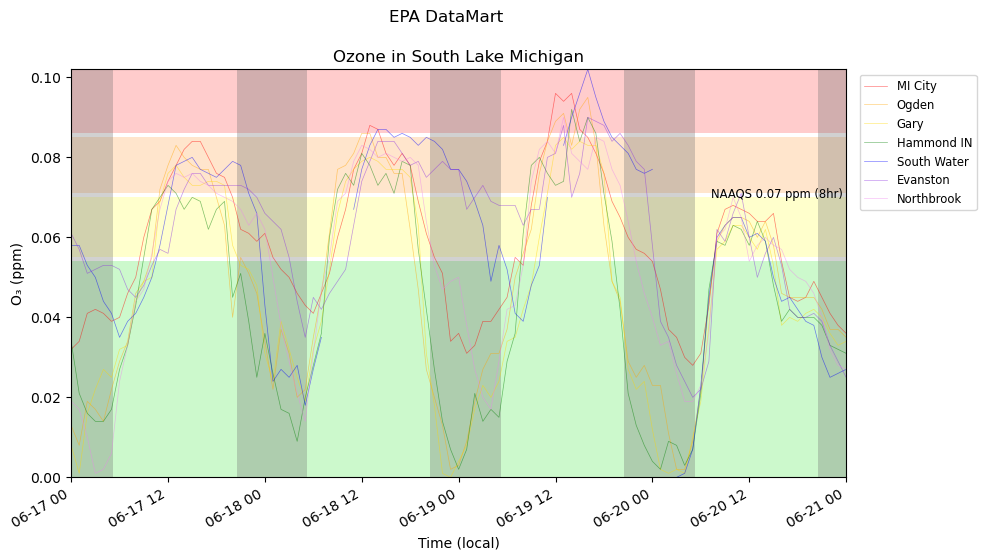

In [ ]:
# Ozone time series along South Lake Michigan
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(10,6),num="SLM Ozone")
fig.suptitle('EPA DataMart')
ax1a = fig.add_subplot(1, #nrows
                1, #ncols
                1) # index position
ax1a.axis([START_DT,END_DT,0,o3_max_SLM])
ax1a.set_title('Ozone in South Lake Michigan')
    
for box in aqi_boxes("o3_8hr", START_DT, END_DT, o3_max_SLM):
    ax1a.add_patch(box)

# Night before first sunrise
ax1a.add_patch(Rectangle(
    (START_DT, 0),
    sunrise[0] - START_DT,
    o3_max_SLM,
    facecolor="dimgray", alpha=0.3
))

# Each subsequent night
for i in range(Ndays):
    ax1a.add_patch(Rectangle(
        (sunset[i], 0),
        sunrise[i+1] - sunset[i],
        o3_max_SLM,
        facecolor="dimgray", alpha=0.3
    ))

ax1a.plot(MI_City_o3['datetime_local'],
        MI_City_o3['sample_measurement'],
        label='MI City',
        linestyle='solid',
        linewidth=0.5,
        color='red',
        alpha=0.5)
ax1a.plot(Ogden_o3['datetime_local'],
          Ogden_o3['sample_measurement'],
           label='Ogden',
           linestyle='solid',
           linewidth=0.5,
           color='orange',
           alpha=0.5)
ax1a.plot(Gary_o3['datetime_local'],
        Gary_o3['sample_measurement'],
        label='Gary',
        linestyle='solid',
        linewidth=0.5,
        color='gold',
        alpha=0.5)
ax1a.plot(Hammond_o3['datetime_local'],
        Hammond_o3['sample_measurement'],
        label='Hammond IN',
        linestyle='solid',
        linewidth=0.5,
        color='green',
        alpha=0.5)
ax1a.plot(South_Water_o3['datetime_local'],
        South_Water_o3['sample_measurement'],
        label='South Water',
        linestyle='solid',
        linewidth=0.5,
        color='blue',
        alpha=0.5)
ax1a.plot(Evanston_o3['datetime_local'],
        Evanston_o3['sample_measurement'],
        label='Evanston',
        linestyle='solid',
        linewidth=0.5,
        color='blueviolet',
        alpha=0.5)
ax1a.plot(Northbrook_o3['datetime_local'],
        Northbrook_o3['sample_measurement'],
        label='Northbrook',
        linestyle='solid',
        linewidth=0.5,
        color='violet',
        alpha=0.5)
ax1a.set_ylabel(f"{o3.symbol} ({o3.units})")  # → "O₃ (ppm)"
ax1a.set_xlabel('Time (local)')
ax1a.text(END_DT,0.07,'NAAQS 0.07 ppm (8hr) ',size='smaller',horizontalalignment='right')

ax1a.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')

fig.autofmt_xdate()

In [41]:
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/SLM_ozone.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/SLM_ozone.pdf", bbox_inches="tight")
print("Saved SLM figures")

Saved SLM figures


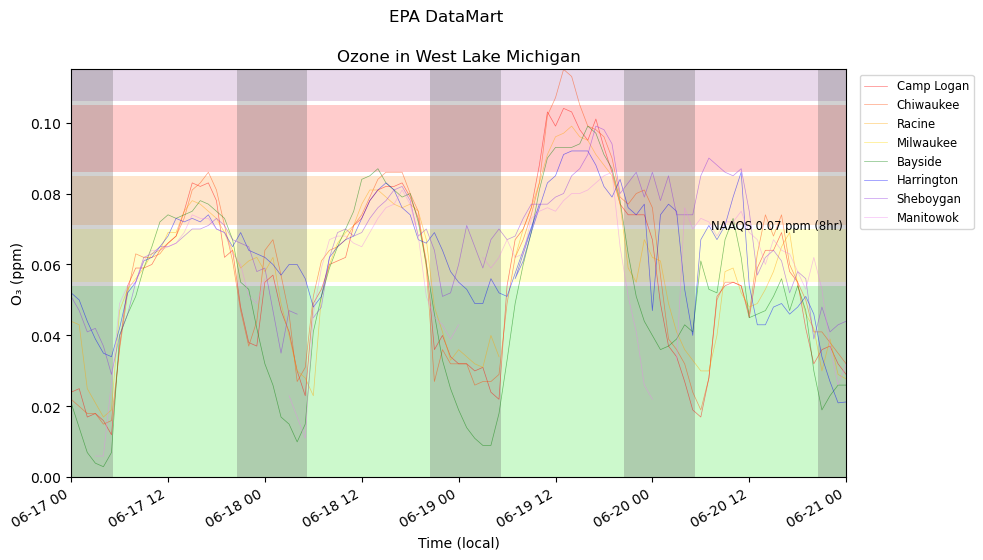

In [50]:
# Ozone time series along West Lake Michigan

fig2 = plt.figure(figsize=(10,6),num="WLM Ozone")
fig2.suptitle('EPA DataMart')
ax2a = fig2.add_subplot(1, #nrows
                1, #ncols
                1) # index position
ax2a.axis([START_DT,END_DT,0,o3_max_WLM])
ax2a.set_title('Ozone in West Lake Michigan')

for box in aqi_boxes("o3_8hr", START_DT, END_DT, o3_max_WLM):
    ax2a.add_patch(box)

# Night before first sunrise
ax2a.add_patch(Rectangle(
    (START_DT, 0),
    sunrise[0] - START_DT,
    o3_max_WLM,
    facecolor="dimgray", alpha=0.3
))

# Each subsequent night
for i in range(Ndays):
    ax2a.add_patch(Rectangle(
        (sunset[i], 0),
        sunrise[i+1] - sunset[i],
        o3_max_WLM,
        facecolor="dimgray", alpha=0.3
    ))

ax2a.plot(Camp_Logan_o3['datetime_local'],
        Camp_Logan_o3['sample_measurement'],
        label='Camp Logan',
        linestyle='solid',
        linewidth=0.5,
        color='red',
        alpha=0.5)
ax2a.plot(Chiwaukee_o3['datetime_local'],
        Chiwaukee_o3['sample_measurement'],
        label='Chiwaukee',
        linestyle='solid',
        linewidth=0.5,
        color='orangered',
        alpha=0.5)
ax2a.plot(Racine_o3['datetime_local'],
        Racine_o3['sample_measurement'],
        label='Racine',
        linestyle='solid',
        linewidth=0.5,
        color='orange',
        alpha=0.5)
ax2a.plot(Milwaukee_o3['datetime_local'],
        Milwaukee_o3['sample_measurement'],
        label='Milwaukee',
        linestyle='solid',
        linewidth=0.5,
        color='gold',
        alpha=0.5)
ax2a.plot(Bayside_o3['datetime_local'],
        Bayside_o3['sample_measurement'],
        label='Bayside',
        linestyle='solid',
        linewidth=0.5,
        color='green',
        alpha=0.5)           
ax2a.plot(Harrington_o3['datetime_local'],
        Harrington_o3['sample_measurement'],
        label='Harrington',
        linestyle='solid',
        linewidth=0.5,
        color='blue',
        alpha=0.5)
ax2a.plot(Sheboygan_o3['datetime_local'],
        Sheboygan_o3['sample_measurement'],
        label='Sheboygan',
        linestyle='solid',
        linewidth=0.5,
        color='blueviolet',
        alpha=0.5)
ax2a.plot(Manitowoc_o3['datetime_local'],
        Manitowoc_o3['sample_measurement'],
        label='Manitowok',
        linestyle='solid',
        linewidth=0.5,
        color='violet',
        alpha=0.5)           
ax2a.set_ylabel(f"{o3.symbol} ({o3.units})")  # → "O₃ (ppm)"
ax2a.set_xlabel('Time (local)')
ax2a.text(END_DT,0.07,'NAAQS 0.07 ppm (8hr) ',size='smaller',horizontalalignment='right')
ax2a.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')

fig2.autofmt_xdate()

In [44]:
fig2.savefig("figures/WLM_ozone.png", dpi=150, bbox_inches="tight")
fig2.savefig("figures/WLM_ozone.pdf", bbox_inches="tight")
print("Saved WLM figures")

Saved WLM figures


## Stations Map

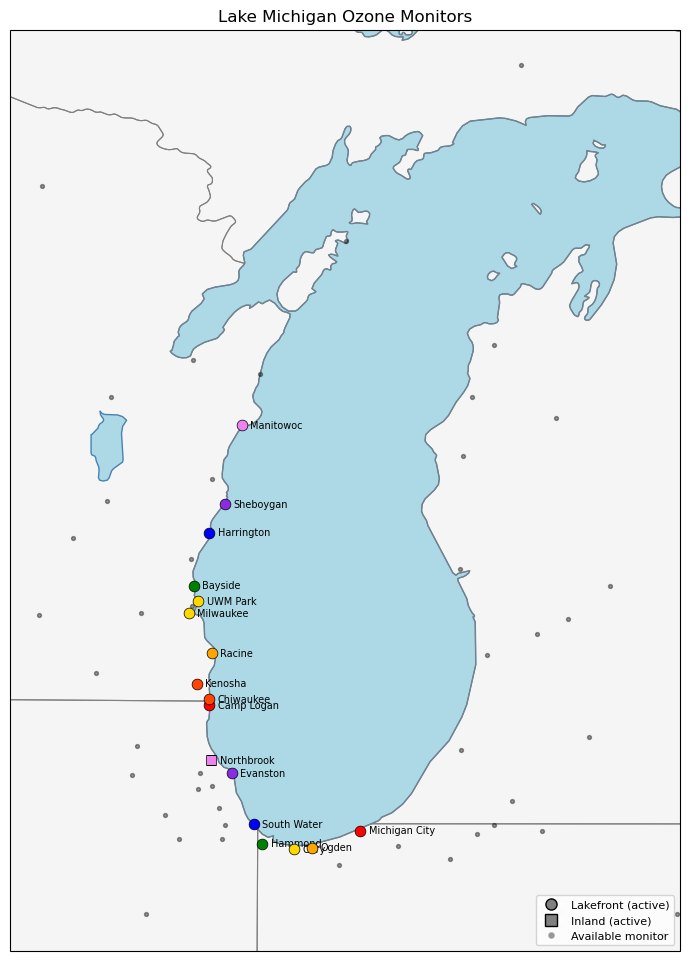

In [51]:
# Requires cartopy: conda install -c conda-forge cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

fig_map, ax_map = plt.subplots(figsize=(7, 10), subplot_kw={"projection": proj})
ax_map.set_extent([-89, -85, 41, 46.5], crs=proj)

# Geographic features
ax_map.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="lightblue", edgecolor="steelblue")
ax_map.add_feature(cfeature.LAND.with_scale("10m"),  facecolor="whitesmoke")
ax_map.add_feature(cfeature.STATES.with_scale("10m"), edgecolor="gray", linewidth=0.8)
ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.5)

# All monitors in bounding box — small black dots
ax_map.scatter(
    lm_o3_monitors["longitude"],
    lm_o3_monitors["latitude"],
    s=8, color="black", alpha=0.4,
    transform=proj,
    label="Available monitors",
    zorder=3,
)

# Active stations — color coded, marker shape encodes lakefront vs inland
for name, info in STATIONS.items():
    marker = "o" if info["lakefront"] else "s"
    ax_map.scatter(
        info["lon"], info["lat"],
        s=60, color=info["color"],
        marker=marker, edgecolors="black", linewidths=0.5,
        transform=proj, zorder=5,
    )
    ax_map.text(
        info["lon"] + 0.05, info["lat"], name,
        transform=proj, fontsize=7, va="center",
    )

ax_map.set_title("Lake Michigan Ozone Monitors")
ax_map.legend(
    handles=[
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="gray",
                   markersize=8, markeredgecolor="black", label="Lakefront (active)"),
        plt.Line2D([0],[0], marker="s", color="w", markerfacecolor="gray",
                   markersize=8, markeredgecolor="black", label="Inland (active)"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="black",
                   markersize=5, alpha=0.4, label="Available monitor"),
    ],
    loc="lower right", fontsize=8,
)
plt.tight_layout()
plt.show()

In [38]:
fig_map.savefig("figures/Ozone_stations.png", dpi=150, bbox_inches="tight")
fig_map.savefig("figures/Ozone_stations.pdf", bbox_inches="tight")
print("Saved stations map")

Saved stations map
